## Deal with incorrect data

In [1]:
import pandas as pd
data = pd.read_csv("Global YouTube Statistics_utf8.csv")
data

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,228000000000,Music,T-Series,20082,India,IN,Music,...,2000000,2006,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,28368841870,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000,2012,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,164000000000,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000,2006,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,148000000000,Shows,SET India,116536,India,IN,Entertainment,...,1000000,2006,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,Natan por Aï¿,12300000,9029609749,Sports,Natan por Aï¿,1200,Brazil,BR,Entertainment,...,700000,2017,Feb,12.0,51.3,2.125594e+08,12.08,183241641.0,-14.235004,-51.925280
991,992,Free Fire India Official,12300000,1674409945,People & Blogs,Free Fire India Official,1500,India,IN,Games,...,300000,2018,Sep,14.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
992,993,Panda,12300000,2214684303,NaN,HybridPanda,2452,United Kingdom,GB,Games,...,1000,2006,Sep,11.0,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973
993,994,RobTopGames,12300000,374123483,Gaming,RobTopGames,39,Sweden,SE,Games,...,100000,2012,May,9.0,67.0,1.028545e+07,6.48,9021165.0,60.128161,18.643501


In [2]:
data['category'].unique()

array(['Music', 'Film & Animation', 'Entertainment', 'Education', 'Shows',
       nan, 'People & Blogs', 'Gaming', 'Sports', 'Howto & Style',
       'News & Politics', 'Vocï¿½ï¿½ï¿?1558', 'Comedy', 'Trailers',
       'Nonprofits & Activism', 'Vlad vï¿½ï¿½?515',
       'La Granja de Zenï¿?654', 'Science & Technology', 'Movies',
       'mariliamendonca', '1theK (ï¿½ï¿½ï¿½ï¿½?18950', 'netd mï¿½ï?23491',
       'Pets & Animals', 'Peppa Pig Espaï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿?1251',
       'Sagawa /ï¿½ï¿½ï¿?6274', 'Autos & Vehicles',
       'Kurzgesagt ï¿½ï¿½ï¿½ï¿½ï¿½ï?193', 'Totoy kids - Portuguï¿?206',
       'Little Angel Espaï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿?719', 'INCRï¿½ï?6903',
       'Sebastiï¿½ï¿½ï¿?237', 'Gato Galactico | GALï¿½ï?1491',
       'With Kids[ï¿½ï¿½ï¿½ï¿½?920', 'Pokï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½ï¿?194',
       'Mohamed Ramadan I ï¿½ï¿½ï¿½ï¿½ï¿½ï¿½?753',
       'Zï¿½ï¿½ï¿½ï¿½ï¿½ï¿½?340', 'Saad Lamjarred | ï¿½ï¿½ï¿½ï¿½ï¿½ï?176',
       'ýýýýýýýýýýýýýýýýýýýý?364', 'Gyan Gamingï¿?3086',
   

In [3]:
import re
pattern = r'^.*[ï¿\d]+.*$'
data['category'] = data['category'].apply(
    lambda x: None if pd.notna(x) and re.match(pattern, x) else x
)
data['category'].unique()

array(['Music', 'Film & Animation', 'Entertainment', 'Education', 'Shows',
       nan, 'People & Blogs', 'Gaming', 'Sports', 'Howto & Style',
       'News & Politics', None, 'Comedy', 'Trailers',
       'Nonprofits & Activism', 'Science & Technology', 'Movies',
       'mariliamendonca', 'Pets & Animals', 'Autos & Vehicles',
       'Travel & Events'], dtype=object)

In [4]:
data['channel_type'].unique()

array(['Music', 'Games', 'Entertainment', 'Education', 'People', 'Sports',
       'Film', 'News', '3800129', '450', '3', nan, 'Comedy', 'Howto',
       'Nonprofit', '28', '2', 'Autos', '69', 'Tech', '4052296',
       '4057142', '6', 'Animals', '12', '278', '19', '16', '566', '25',
       '124', '30', '135', '4048675', '100', '4057925', '548', '36',
       '1364', '1', '14', '107', '2934', '4050736', '2530', '15', '47',
       '166', '13', '1770', '52', '1087'], dtype=object)

In [5]:
import numpy as np

def replace_numbers_with_na(value):
    if pd.isna(value):
        return value
    if str(value).isdigit():
        return np.nan
    else:
        return value

data['channel_type'] = data['channel_type'].apply(replace_numbers_with_na)
data['channel_type'].unique()

array(['Music', 'Games', 'Entertainment', 'Education', 'People', 'Sports',
       'Film', 'News', nan, 'Comedy', 'Howto', 'Nonprofit', 'Autos',
       'Tech', 'Animals'], dtype=object)

In [6]:
import calendar
data['created_year'] = data['created_year'].replace(0, pd.NA)
data['created_date'] = data['created_date'].replace(0, pd.NA)
data['created_month'] = data['created_month'].replace('', pd.NA)

data = data.dropna(subset=['created_year', 'created_month', 'created_date'])

def month_to_num(month_text):
    month_text = str(month_text).strip().lower()
    
    for i in range(1, 13):
        if month_text in [calendar.month_abbr[i].lower(), calendar.month_name[i].lower()]:
            return str(i).zfill(2)
    return pd.NA

data['month_num'] = data['created_month'].apply(month_to_num)

data = data.dropna(subset=['month_num'])

data['date_str'] = (
    data['created_year'].astype(int).astype(str) + '-' +
    data['created_date'].astype(int).astype(str).str.zfill(2) + '-' + 
    data['month_num']
)

data['created_datetime'] = pd.to_datetime(
    data['date_str'], 
    format='%Y-%d-%m',
    errors='coerce'
)

data = data.drop(columns=['month_num', 'date_str'])
data

C:\Users\18817\AppData\Local\Temp\ipykernel_43832\119886611.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['month_num'] = data['created_month'].apply(month_to_num)


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude,created_datetime
0,1,T-Series,245000000,228000000000,Music,T-Series,20082,India,IN,Music,...,2006,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2006-03-13
1,2,YouTube Movies,170000000,0,Film & Animation,youtubemovies,1,United States,US,Games,...,2006,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2006-03-05
2,3,MrBeast,166000000,28368841870,Entertainment,MrBeast,741,United States,US,Entertainment,...,2012,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2012-02-20
3,4,Cocomelon - Nursery Rhymes,162000000,164000000000,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,2006,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,2006-09-01
4,5,SET India,159000000,148000000000,Shows,SET India,116536,India,IN,Entertainment,...,2006,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2006-09-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
990,991,Natan por Aï¿,12300000,9029609749,Sports,Natan por Aï¿,1200,Brazil,BR,Entertainment,...,2017,Feb,12.0,51.3,2.125594e+08,12.08,183241641.0,-14.235004,-51.925280,2017-02-12
991,992,Free Fire India Official,12300000,1674409945,People & Blogs,Free Fire India Official,1500,India,IN,Games,...,2018,Sep,14.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,2018-09-14
992,993,Panda,12300000,2214684303,NaN,HybridPanda,2452,United Kingdom,GB,Games,...,2006,Sep,11.0,60.0,6.683440e+07,3.85,55908316.0,55.378051,-3.435973,2006-09-11
993,994,RobTopGames,12300000,374123483,Gaming,RobTopGames,39,Sweden,SE,Games,...,2012,May,9.0,67.0,1.028545e+07,6.48,9021165.0,60.128161,18.643501,2012-05-09


In [7]:
import numpy as np

numeric_stats = data.drop(['rank','video_views_rank','country_rank','channel_type_rank','created_date'],axis=1).describe(
    include=['int64', 'float64'],
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).round(2)

print("=" * 50)
print("numeric_stats：")
print("=" * 50)
print(numeric_stats)

categorical_cols = ['category', 'channel_type']
categorical_stats = {}

for col in categorical_cols:
    if col in data.columns:
        non_null_count = data[col].notna().sum()
        unique_count = data[col].nunique()
        top_category = data[col].mode().iloc[0] if not data[col].mode().empty else "N/A"
        top_category_ratio = (data[col] == top_category).sum() / non_null_count * 100 if non_null_count > 0 else 0
        
        categorical_stats[col] = {
            'non_null': non_null_count,
            'Na': data[col].isna().sum(),
            'unique_count': unique_count,
            'top_category': top_category,
            'top_category_ratio(%)': round(top_category_ratio, 2)
        }

categorical_stats_df = pd.DataFrame(categorical_stats).T
print("\n" + "=" * 50)
print("categorical_stats：")
print("=" * 50)
print(categorical_stats_df)

if 'created_datetime' in data.columns:
    date_stats = {
        'start_created_datetime': data['created_datetime'].min(),
        'end_created_datetime': data['created_datetime'].max(),
        'Na': data['created_datetime'].isna().sum(),
    }
    
    print("\n" + "=" * 50)
    print("created_datetime:")
    print("=" * 50)
    for key, value in date_stats.items():
        print(f"{key}: {value}")

numeric_stats：
        subscribers  video_views_for_the_last_30_days  \
count  9.450000e+02                      8.950000e+02   
mean   2.313439e+07                      1.794041e+08   
std    1.783133e+07                      4.250612e+08   
min    1.230000e+07                      1.000000e+00   
5%     1.260000e+07                      6.000000e+01   
25%    1.450000e+07                      2.071250e+07   
50%    1.780000e+07                      6.506600e+07   
75%    2.480000e+07                      1.699165e+08   
95%    4.654000e+07                      6.949723e+08   
max    2.450000e+08                      6.589000e+09   

       lowest_monthly_earnings  highest_monthly_earnings  \
count                   945.00                    945.00   
mean                  37692.04                 602744.85   
std                   73256.14                1171054.73   
min                       0.00                      0.00   
5%                        0.00                      0.00 

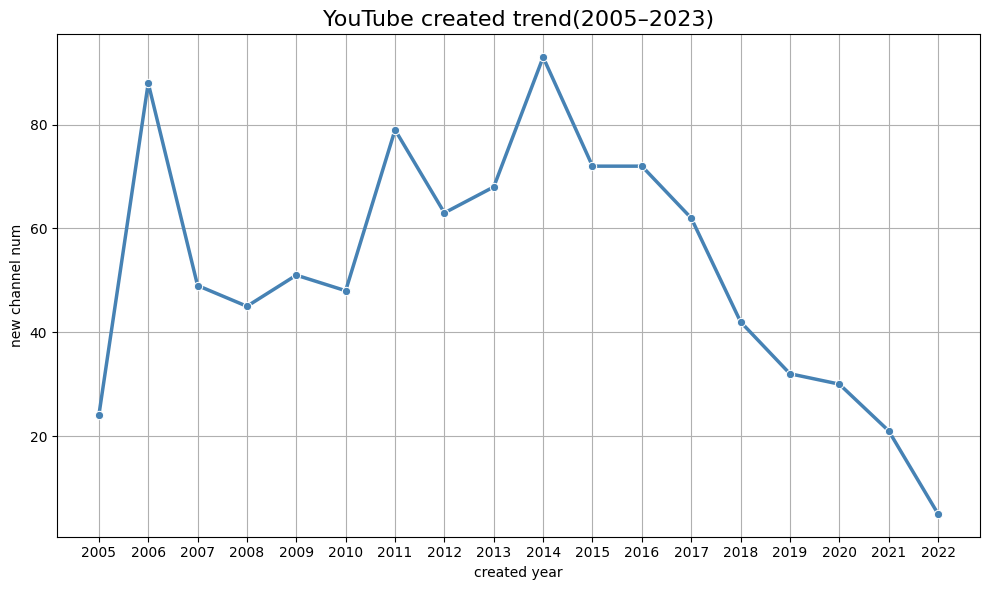

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
yearly_counts = data['created_year'].value_counts().sort_index()
yearly_counts = yearly_counts[(yearly_counts.index >= '2005') & (yearly_counts.index <= '2023')]

sns.lineplot(x=yearly_counts.index, y=yearly_counts.values, marker='o', linewidth=2.5, color='steelblue')
plt.title('YouTube created trend(2005–2023)', fontsize=16)
plt.xlabel('created year')
plt.ylabel('new channel num')
plt.set_cmap('viridis')
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
import plotly.express as px

df = data.copy()

df = df.dropna(subset=['Country', 'category', 'Latitude', 'Longitude'])
df = df[df['category'].str.strip() != '']

def most_common_category(group):
    mode_series = group['category'].mode()
    return mode_series.iloc[0] if not mode_series.empty else 'Other'

country_category = df.groupby('Country').apply(most_common_category).reset_index(name='Dominant_Category')
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Channel_Count']
country_summary = country_category.merge(country_counts, on='Country')

coords = df[['Country', 'Latitude', 'Longitude']].drop_duplicates(subset='Country')
country_summary = country_summary.merge(coords, on='Country')

country_summary['Dominant_Category'] = country_summary['Dominant_Category'].str.strip()

fig = px.scatter_geo(
    country_summary,
    lat='Latitude',
    lon='Longitude',
    color='Dominant_Category',
    hover_name='Country',
    hover_data={'Channel_Count': True},
    size='Channel_Count',
    size_max=40,
    projection='orthographic',
    title='Dominant YouTube Channel Category by Country',
    template='plotly_dark'
)

fig.update_layout(
    title_font_size=22,
    legend_title_text='channel category',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.1,
        xanchor="center",
        x=0.5
    ),
    width=1200,
    height=800,
    margin={"r":0,"t":60,"l":0,"b":60}
)

fig.show()

C:\Users\18817\AppData\Local\Temp\ipykernel_43832\3736867676.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  country_category = df.groupby('Country').apply(most_common_category).reset_index(name='Dominant_Category')



Cluster Centroids (Original Scale):
     Population  Gross tertiary education enrollment (%)  Unemployment rate  \
0  7.219829e+07                                53.475000          11.115000   
1  1.382066e+09                                39.350000           4.840000   
2  6.227517e+07                                59.410345           3.992759   

   Urban_population  
0      5.498029e+07  
1      6.569827e+08  
2      3.898134e+07  


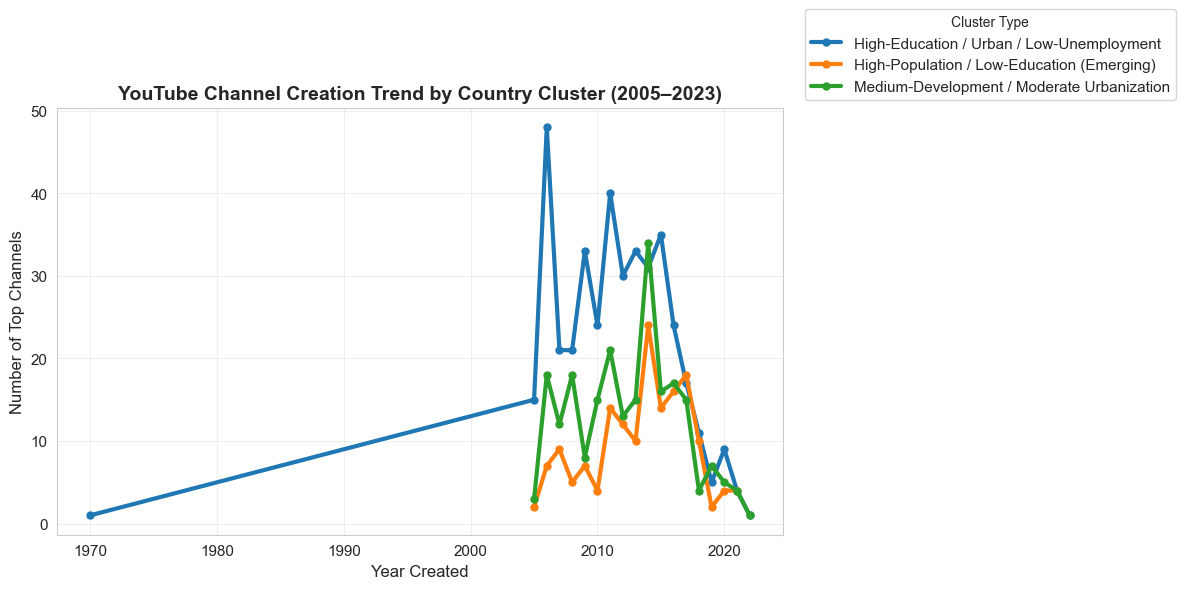

C:\Users\18817\AppData\Local\Temp\ipykernel_43832\3469978183.py:73: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




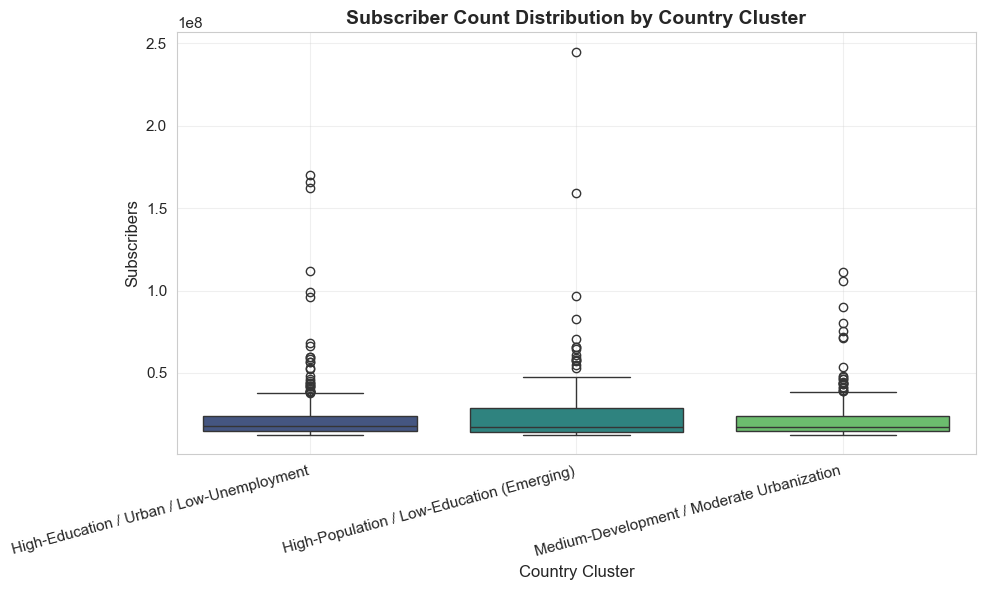

C:\Users\18817\AppData\Local\Temp\ipykernel_43832\3469978183.py:83: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




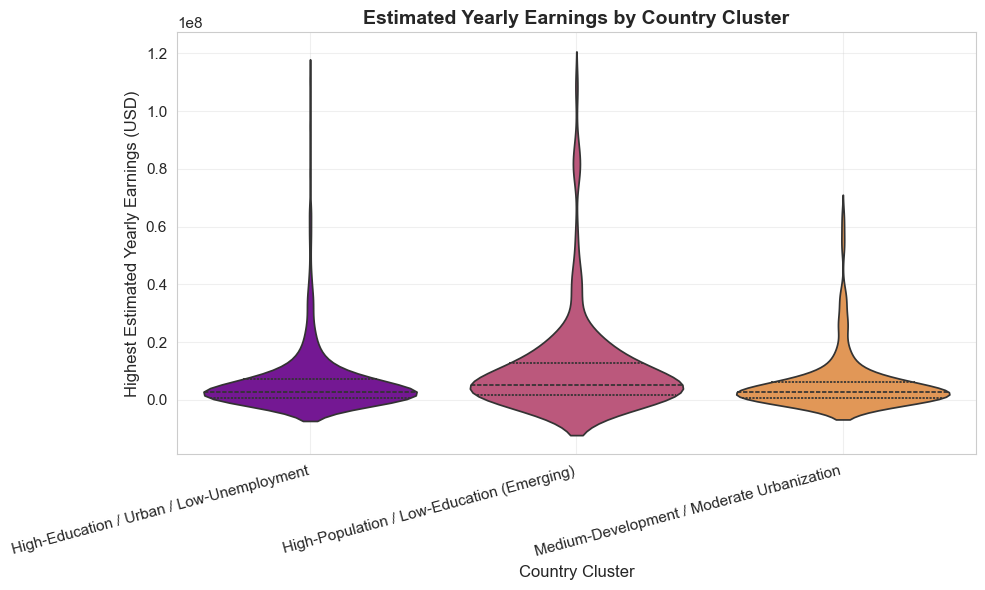

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.titlesize'] = 14
sns.set_style("whitegrid")

df = data.copy()

required_cols = [
    'Country', 'category', 'created_year', 'subscribers', 'highest_yearly_earnings',
    'Population', 'Gross tertiary education enrollment (%)', 'Unemployment rate', 'Urban_population'
]
df = df.dropna(subset=required_cols)

for col in ['subscribers', 'created_year', 'highest_yearly_earnings', 'Population']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['subscribers', 'created_year', 'highest_yearly_earnings', 'Population'])

country_socio = df[[
    'Country', 'Population', 'Gross tertiary education enrollment (%)',
    'Unemployment rate', 'Urban_population'
]].drop_duplicates()

features = [
    'Population',
    'Gross tertiary education enrollment (%)',
    'Unemployment rate',
    'Urban_population'
]
X = country_socio[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
country_socio['Cluster'] = kmeans.fit_predict(X_scaled)

df = df.merge(country_socio[['Country', 'Cluster']], on='Country', how='left')
df = df.dropna(subset=['Cluster'])
df['Cluster'] = df['Cluster'].astype(int)

centers = scaler.inverse_transform(kmeans.cluster_centers_)
print("\nCluster Centroids (Original Scale):")
print(pd.DataFrame(centers, columns=features))

cluster_labels = {
    0: 'High-Education / Urban / Low-Unemployment',
    1: 'High-Population / Low-Education (Emerging)',
    2: 'Medium-Development / Moderate Urbanization'
}

plt.figure(figsize=(12, 6))
for cluster in range(3):
    subset = df[df['Cluster'] == cluster]
    if not subset.empty:
        yearly = subset['created_year'].value_counts().sort_index()
        plt.plot(yearly.index, yearly.values, label=cluster_labels[cluster], linewidth=3, marker='o', markersize=5)

plt.title('YouTube Channel Creation Trend by Country Cluster (2005–2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year Created')
plt.ylabel('Number of Top Channels')
plt.legend(title='Cluster Type', bbox_to_anchor=(1.02, 1), loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Cluster', y='subscribers', palette='viridis')
plt.xticks(ticks=[0,1,2], labels=[cluster_labels[i] for i in range(3)], rotation=15, ha='right')
plt.title('Subscriber Count Distribution by Country Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Subscribers')
plt.xlabel('Country Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Cluster', y='highest_yearly_earnings', palette='plasma', inner="quartile")
plt.xticks(ticks=[0,1,2], labels=[cluster_labels[i] for i in range(3)], rotation=15, ha='right')
plt.title('Estimated Yearly Earnings by Country Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Highest Estimated Yearly Earnings (USD)')
plt.xlabel('Country Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

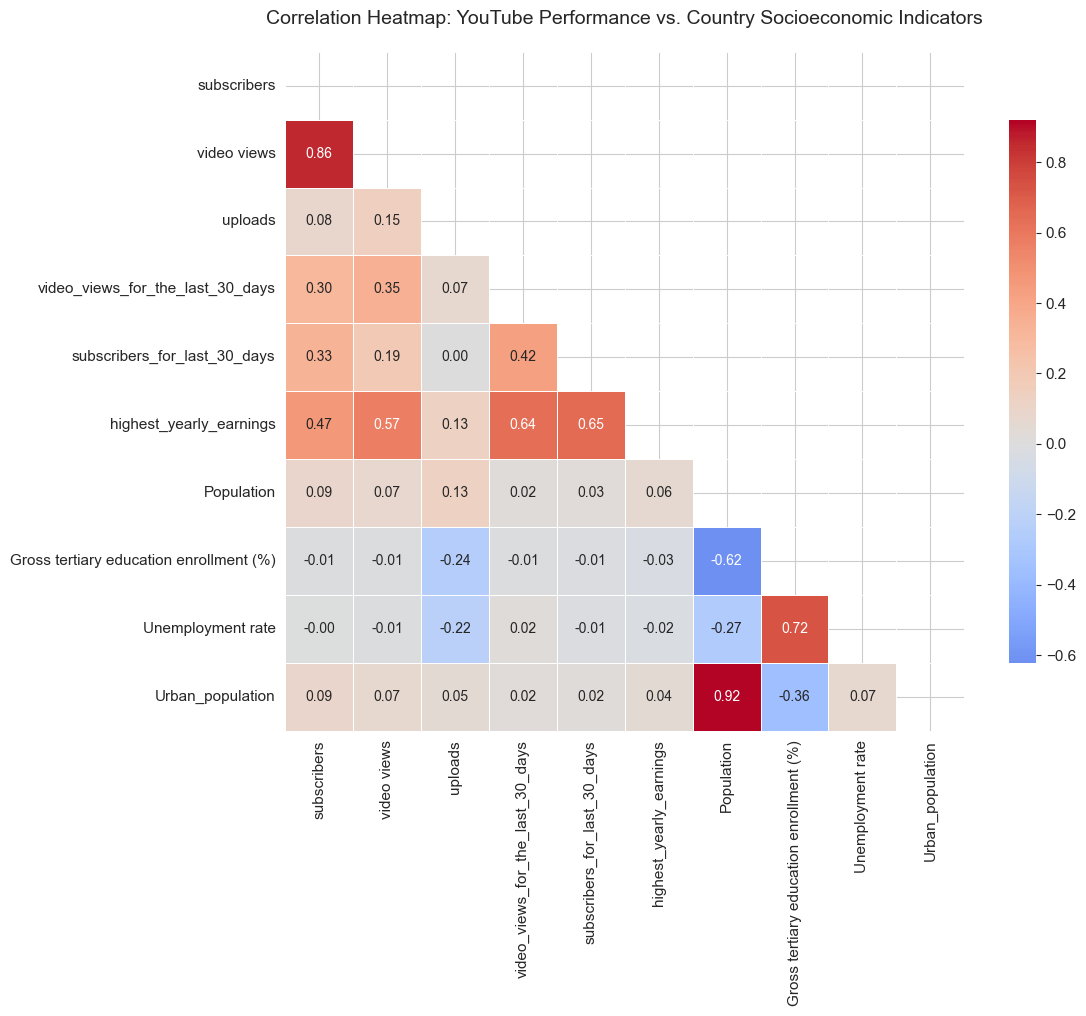

In [11]:
df = data.copy()

numeric_cols = [
    'subscribers',
    'video views',
    'uploads',
    'video_views_for_the_last_30_days',
    'subscribers_for_last_30_days',
    'highest_yearly_earnings',
    'Population',
    'Gross tertiary education enrollment (%)',
    'Unemployment rate',
    'Urban_population'
]

df_clean = df[numeric_cols]
df_clean = df_clean.replace(',', '', regex=True)
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.dropna()

corr = df_clean.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Correlation Heatmap: YouTube Performance vs. Country Socioeconomic Indicators', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

features = data.select_dtypes(include='number').drop(['subscribers','rank'], axis=1)
target = data['subscribers']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [14]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


R² Score: 0.3620028631518133
RMSE: 65880089090427.17


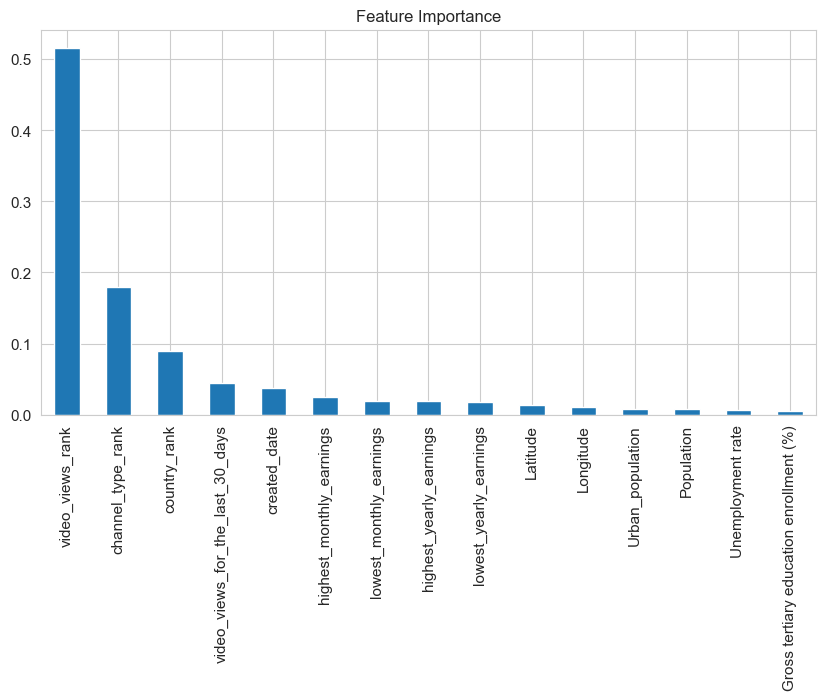

In [15]:
y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))
importances = pd.Series(model.feature_importances_, index=features.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5), title='Feature Importance')
plt.show()

In [17]:
data.to_csv('forR_.csv')